# 05 — Isolation Forest Anomaly Detection

Unsupervised anomaly scoring over the behavioral features. Fit on the first 70% (past), evaluated on the final 20% (future) — identical split to notebooks 04/06. Scaling and log transforms are **train-fitted only** (IsolationForest is not scale-invariant; verified empirically).

**v2 change:** reads `model_features.csv`; anomaly feature set unchanged by design.

In [1]:
# CELL 1 - Load + sort chronologically (same design as 04)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

df = pd.read_csv("../data/processed/model_features.csv")   # v2: encoded features
df["TransactionDT"] = pd.to_datetime(df["TransactionDT"])
df = df.sort_values("TransactionDT").reset_index(drop=True)

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
print(f"Loaded: {df.shape}")

Loaded: (590540, 84)


In [2]:
# CELL 2 - Anomaly feature set (stays behavioral by design)
if "velocity_risk" not in df.columns:
    df["velocity_risk"] = (
        df["txn_count_1h"] / df["txn_count_24h"].clip(lower=1)
    ).clip(0, 1)

anomaly_features = [
    "TransactionAmt",
    "txn_count_1h", "txn_count_24h", "txn_count_7d", "velocity_risk",
    "avg_amt_24h", "amount_dev_24h", "amount_zscore_24h",
    "is_night_txn", "no_prior_24h",
]
missing = [f for f in anomaly_features if f not in df.columns]
assert not missing, f"Missing columns: {missing} - re-run notebooks 01-03b first"

In [3]:
# CELL 3 - Time-based fit/test windows (match notebook 04 exactly)
n = len(df)
train_end = int(n * 0.70)
test_start = int(n * 0.80)

test_mask = df.index >= test_start
print(f"fit window:      {train_end:,} rows (past)")
print(f"evaluate window: {test_mask.sum():,} rows (future)")

fit window:      413,378 rows (past)
evaluate window: 118,108 rows (future)


In [9]:
# CELL 4 - Transform + train Isolation Forest on PAST data only
from sklearn.preprocessing import StandardScaler

log_cols = ["TransactionAmt", "txn_count_1h", "txn_count_24h",
            "txn_count_7d", "avg_amt_24h"]

X_all = df[anomaly_features].copy()
for c in log_cols:
    X_all[c] = np.log1p(X_all[c])

X_train = X_all.iloc[:train_end]

scaler = StandardScaler().fit(X_train)          # fit on past only
X_train_s = scaler.transform(X_train)
X_all_s = scaler.transform(X_all)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42,
    n_jobs=-1,
)
# One-class training: fit on non-fraud rows of the train window only
y_train_all = df["isFraud"].iloc[:train_end]
iso.fit(X_train_s[y_train_all.to_numpy() == 0])

print(f"Fitted on {(y_train_all == 0).sum():,} legitimate past transactions.")
print(f"Fitted on {len(X_train):,} past transactions.")

Fitted on 398,840 legitimate past transactions.
Fitted on 413,378 past transactions.


In [10]:
# CELL 5 - Score all rows; normalize with TRAIN-window stats only
raw = -iso.score_samples(X_all_s)

train_raw = raw[:train_end]
lo, hi = train_raw.min(), train_raw.max()
df["anomaly_score"] = np.clip((raw - lo) / (hi - lo), 0, 1)

In [11]:
# CELL 6 - Evaluate on the held-out FUTURE window
yt = df.loc[test_mask, "isFraud"].to_numpy()
sc = df.loc[test_mask, "anomaly_score"].to_numpy()
base = yt.mean()

top_k = max(1, int(0.03 * len(sc)))
top_idx = np.argsort(sc)[-top_k:]
lift = yt[top_idx].mean() / base

print("TEST (future window) - anomaly_score performance:")
print(f"  ROC-AUC: {roc_auc_score(yt, sc):.4f}")
print(f"  PR-AUC:  {average_precision_score(yt, sc):.4f}   (baseline = {base:.4f})")
print(f"  fraud rate in top 3% scores: {yt[top_idx].mean():.2%}  ({lift:.1f}x lift)\n")
print(df.loc[test_mask].groupby("isFraud")["anomaly_score"].mean().round(4))

TEST (future window) - anomaly_score performance:
  ROC-AUC: 0.5631
  PR-AUC:  0.0402   (baseline = 0.0344)
  fraud rate in top 3% scores: 3.13%  (0.9x lift)

isFraud
0    0.2089
1    0.2352
Name: anomaly_score, dtype: float64


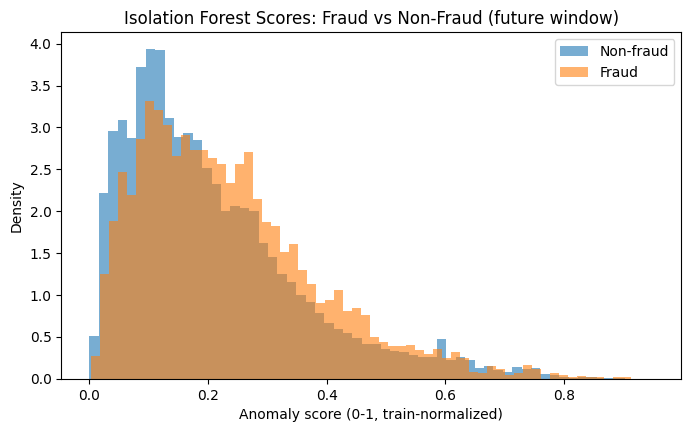

In [12]:
# CELL 7 - Score distributions (test window), saved
test_df = df.loc[test_mask]
plt.figure(figsize=(8, 4.5))
plt.hist(test_df.loc[test_df.isFraud == 0, "anomaly_score"],
         bins=60, alpha=0.6, density=True, label="Non-fraud")
plt.hist(test_df.loc[test_df.isFraud == 1, "anomaly_score"],
         bins=60, alpha=0.6, density=True, label="Fraud")
plt.xlabel("Anomaly score (0-1, train-normalized)")
plt.ylabel("Density")
plt.title("Isolation Forest Scores: Fraud vs Non-Fraud (future window)")
plt.legend()
plt.savefig("../reports/iforest_score_distribution.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [13]:
# CELL 8 - Save enriched CSV + model bundle
import joblib

df.to_csv("../data/processed/fraud_features_with_anomaly_iforest.csv",
          index=False)

joblib.dump(
    {"model": iso, "scaler": scaler,
     "log_cols": log_cols, "features": anomaly_features,
     "score_min": float(lo), "score_max": float(hi)},
    "../models/iforest_anomaly_model.pkl",
)
print(f"Saved CSV: {df.shape}")
print("Saved model bundle -> ../models/iforest_anomaly_model.pkl")

Saved CSV: (590540, 85)
Saved model bundle -> ../models/iforest_anomaly_model.pkl
